**Helper Functions**


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_images_plt(titles, images, figsize=(14,10), cols=2):
    import math
    n = len(images)
    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)
    for i, (t, im) in enumerate(zip(titles, images), 1):
        plt.subplot(rows, cols, i)
        if len(im.shape) == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(im)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    
def show_images_cv2(titles, images):
    for title, img in zip(titles, images):
        cv2.imshow(title, img)
    cv2.waitKey(0)       
    cv2.destroyAllWindows()


## Question 1

For the image toys.gif

**A)** Read and display the image.  
**B)** Compute the 2-D FFT of the image and display one full-scaled copy of the magnitude spectrum.  

**Explanation**

**2-D FFT (Fast Fourier Transform)**
- The 2-D FFT converts an image from the spatial domain to the frequency domain.
- It decomposes the image into its frequency components, showing how much of each frequency is present.
- `np.fft.fft2()` computes the 2D FFT of the image.

**Magnitude Spectrum**
- The magnitude spectrum shows the strength of each frequency component in the image.
- Bright spots in the magnitude spectrum indicate strong frequency components at those locations.
- The center of the spectrum (after `fftshift`) represents low frequencies (DC component and smooth regions).
- Edges and fine details appear as high frequencies, typically away from the center.
- Logarithmic scaling (`np.log(1 + magnitude)`) is used because the magnitude values can span many orders of magnitude, making visualization easier.


<img src="./required-files/toys.GIF" width="200" height="200"/>

Image shape: (512, 512)
Image dtype: uint8


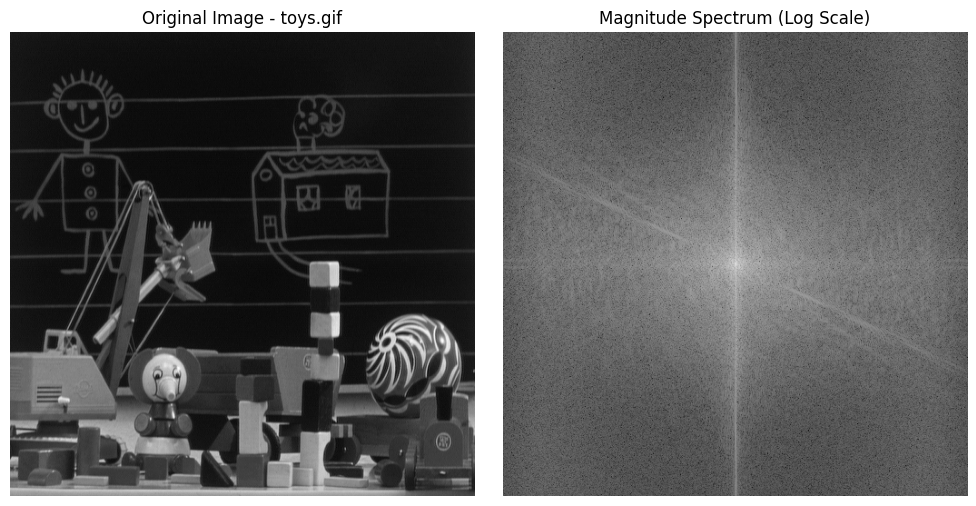

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/saeedm/Documents/image-processing/myenv/lib/python3.13/site-packages/cv2/qt/plugins"


In [3]:
# Question 1: FFT Analysis of toys.gif

# A) Read and display the image
img = cv2.imread('./required-files/toys.GIF', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not load image")
else:
    print(f"Image shape: {img.shape}")
    print(f"Image dtype: {img.dtype}")
    
    # Display original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image - toys.gif')
    plt.axis('off')
    
    # B) Compute 2-D FFT and display magnitude spectrum
    # Compute FFT
    fft = np.fft.fft2(img)
    
    # Shift zero frequency to center
    fft_shifted = np.fft.fftshift(fft)
    
    # Compute magnitude spectrum
    magnitude = np.abs(fft_shifted)
    
    # Apply logarithmic scaling for better visualization
    magnitude_log = np.log(1 + magnitude)
    
    # Display magnitude spectrum (full-scaled)
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_log, cmap='gray')
    plt.title('Magnitude Spectrum (Log Scale)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Optional: Display using cv2
    cv2.imshow("Original Image", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


## Question 2

For the image pepper.jpg, it is required to study the ringing effect of the Butterworth lowpass filter. Design the following filters and investigate the effect of changing the filter order and cutoff frequency on ringing. You need to display the filtered images and the shape of the filters in the spatial domain. A cross-sectional view of the filters in the spatial domain is required. Make sure to display the figures in a neat and organized way.

| Filter Number | Order | Cutoff Frequency |
|----------|----------|----------|
| 1 | 1 | 50 |
| 2 | 1 | 150 |
| 3 | 5 | 50 |
| 4 | 5 | 150 |

<img src="./required-files/pepper.jpg" width="200" height="200"/>

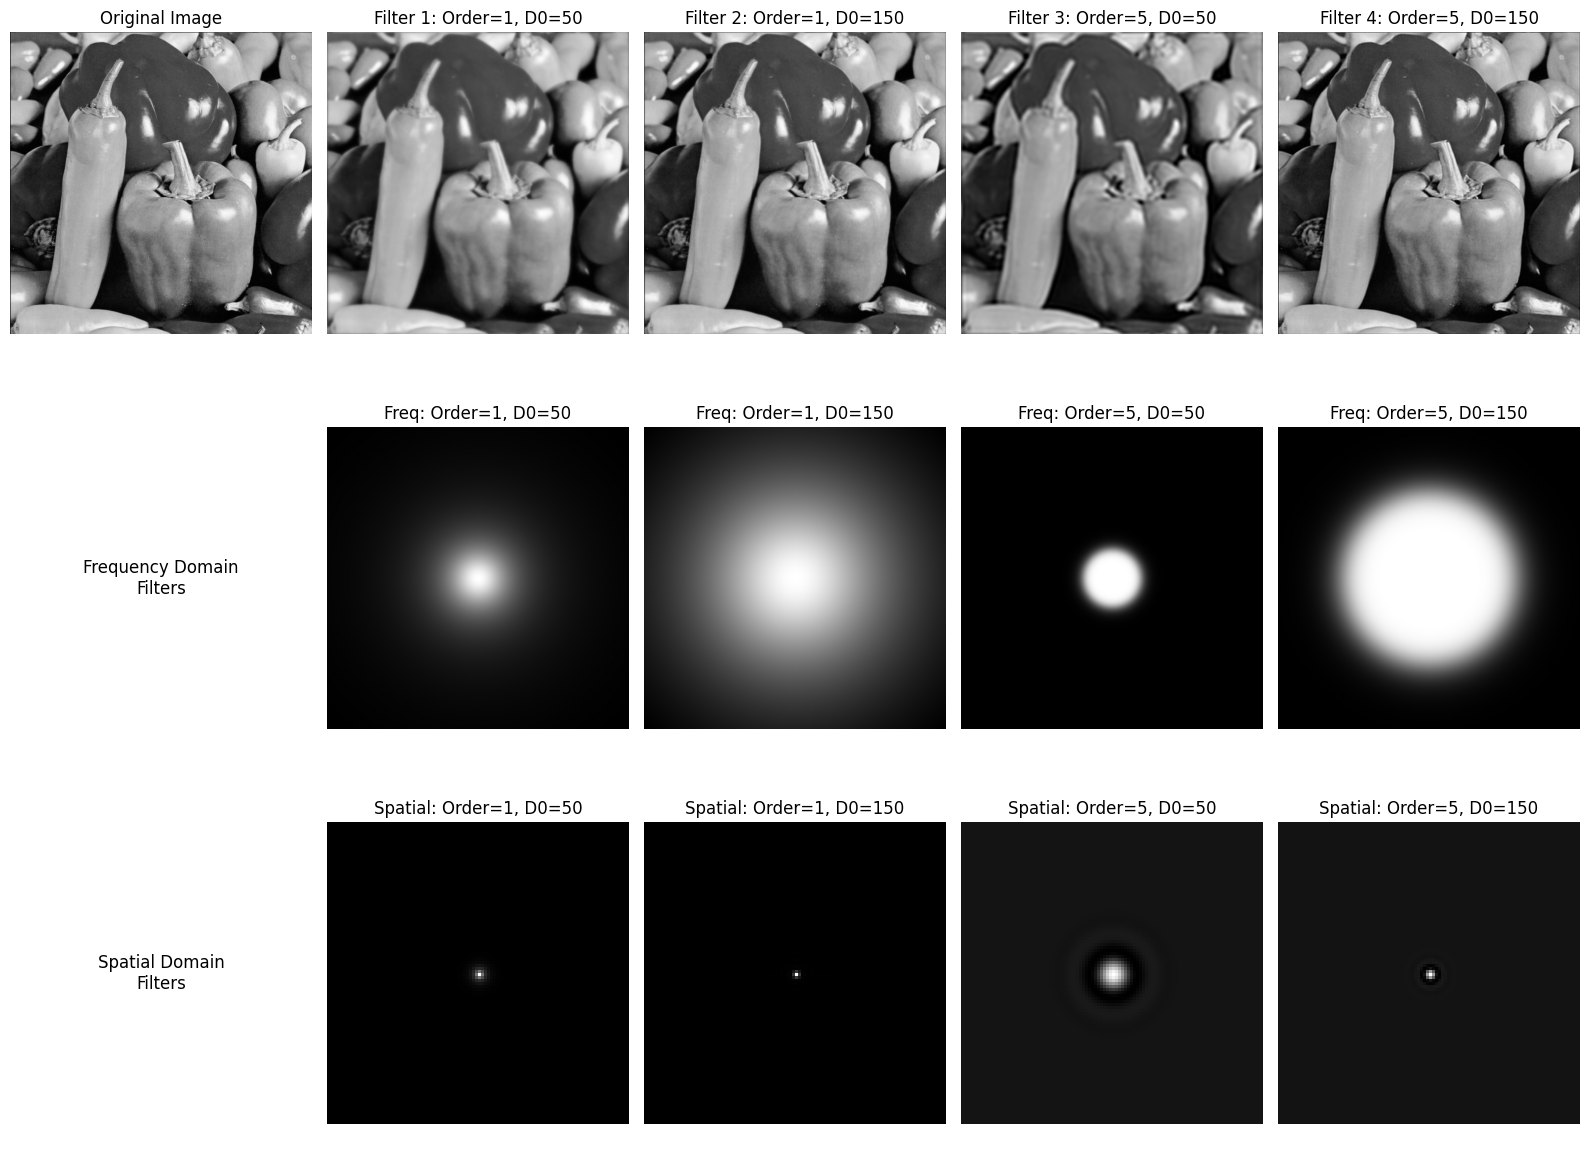

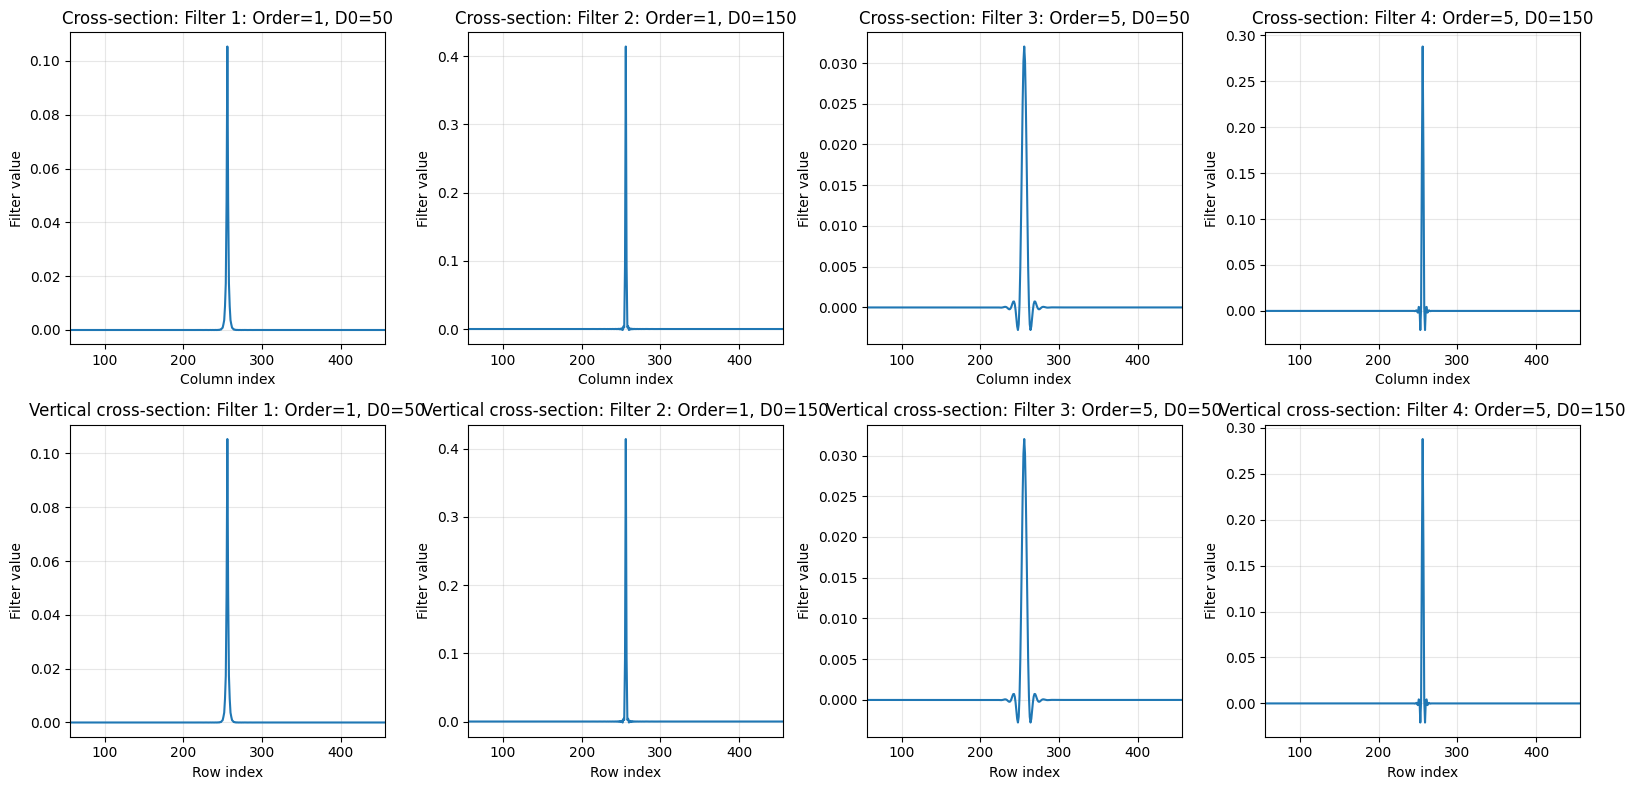

In [5]:
# Question 2: Butterworth Lowpass Filter - Ringing Effect Study

# Read the image
img = cv2.imread('./required-files/pepper.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Could not load pepper.jpg")
else:
    rows, cols = img.shape
    center_row, center_col = rows // 2, cols // 2
    
    # Create frequency domain coordinates
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    # Distance from center (frequency domain)
    D = np.sqrt((u - center_row)**2 + (v - center_col)**2)
    
    # Filter parameters
    filters = [
        {'order': 1, 'D0': 50, 'name': 'Filter 1: Order=1, D0=50'},
        {'order': 1, 'D0': 150, 'name': 'Filter 2: Order=1, D0=150'},
        {'order': 5, 'D0': 50, 'name': 'Filter 3: Order=5, D0=50'},
        {'order': 5, 'D0': 150, 'name': 'Filter 4: Order=5, D0=150'}
    ]
    
    # Compute FFT of original image
    fft_img = np.fft.fft2(img)
    fft_img_shifted = np.fft.fftshift(fft_img)
    
    filtered_images = []
    filter_freq_domain = []
    filter_spatial_domain = []
    
    for filter_params in filters:
        n = filter_params['order']
        D0 = filter_params['D0']
        
        # Butterworth lowpass filter in frequency domain
        # H(u,v) = 1 / (1 + (D(u,v)/D0)^(2n))
        H = 1 / (1 + (D / D0)**(2*n))
        filter_freq_domain.append(H)
        
        # Apply filter in frequency domain
        filtered_fft = fft_img_shifted * H
        filtered_fft_ishifted = np.fft.ifftshift(filtered_fft)
        filtered_img = np.real(np.fft.ifft2(filtered_fft_ishifted))
        filtered_img = np.clip(filtered_img, 0, 255).astype(np.uint8)
        filtered_images.append(filtered_img)
        
        # Convert filter to spatial domain
        # Create a filter in frequency domain, then take inverse FFT
        filter_spatial = np.real(np.fft.ifft2(np.fft.ifftshift(H)))
        filter_spatial = np.fft.fftshift(filter_spatial)  # Center it
        filter_spatial_domain.append(filter_spatial)
    
    # Display filtered images
    plt.figure(figsize=(16, 12))
    
    # First row: Original and filtered images
    plt.subplot(3, 5, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    for i, (filtered_img, filter_params) in enumerate(zip(filtered_images, filters), 2):
        plt.subplot(3, 5, i)
        plt.imshow(filtered_img, cmap='gray')
        plt.title(filter_params['name'])
        plt.axis('off')
    
    # Second row: Filters in frequency domain
    plt.subplot(3, 5, 6)
    plt.text(0.5, 0.5, 'Frequency Domain\nFilters', 
             ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
    plt.axis('off')
    
    for i, (H, filter_params) in enumerate(zip(filter_freq_domain, filters), 7):
        plt.subplot(3, 5, i)
        plt.imshow(H, cmap='gray')
        plt.title(f"Freq: Order={filter_params['order']}, D0={filter_params['D0']}")
        plt.axis('off')
    
    # Third row: Filters in spatial domain
    plt.subplot(3, 5, 11)
    plt.text(0.5, 0.5, 'Spatial Domain\nFilters', 
             ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
    plt.axis('off')
    
    for i, (filter_spatial, filter_params) in enumerate(zip(filter_spatial_domain, filters), 12):
        plt.subplot(3, 5, i)
        # Display center region for better visualization
        center_size = 100
        start_row = center_row - center_size // 2
        end_row = center_row + center_size // 2
        start_col = center_col - center_size // 2
        end_col = center_col + center_size // 2
        filter_center = filter_spatial[start_row:end_row, start_col:end_col]
        plt.imshow(filter_center, cmap='gray')
        plt.title(f"Spatial: Order={filter_params['order']}, D0={filter_params['D0']}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display cross-sectional views of filters in spatial domain
    plt.figure(figsize=(16, 8))
    
    for idx, (filter_spatial, filter_params) in enumerate(zip(filter_spatial_domain, filters), 1):
        # Extract cross-section through center (middle row)
        cross_section = filter_spatial[center_row, :]
        
        plt.subplot(2, 4, idx)
        plt.plot(cross_section)
        plt.title(f"Cross-section: {filter_params['name']}")
        plt.xlabel('Column index')
        plt.ylabel('Filter value')
        plt.grid(True, alpha=0.3)
        plt.xlim(center_col - 200, center_col + 200)  # Show center region
    
    # Also show vertical cross-section
    for idx, (filter_spatial, filter_params) in enumerate(zip(filter_spatial_domain, filters), 5):
        # Extract cross-section through center (middle column)
        cross_section = filter_spatial[:, center_col]
        
        plt.subplot(2, 4, idx)
        plt.plot(cross_section)
        plt.title(f"Vertical cross-section: {filter_params['name']}")
        plt.xlabel('Row index')
        plt.ylabel('Filter value')
        plt.grid(True, alpha=0.3)
        plt.xlim(center_row - 200, center_row + 200)  # Show center region
    
    plt.tight_layout()
    plt.show()
    
    # Optional: Display using cv2
    show_images_cv2(['Original'] + [f['name'] for f in filters], 
                    [img] + filtered_images)


**Explanation: Ringing Effect and Filter Characteristics**

**Butterworth Lowpass Filter**
- Formula: `H(u,v) = 1 / (1 + (D(u,v)/D0)^(2n))`
- `D(u,v)`: Distance from center in frequency domain
- `D0`: Cutoff frequency
- `n`: Filter order

**Ringing Effect**
- Ringing appears as oscillations or "ripples" near sharp edges in filtered images.
- It occurs because ideal filters have sharp transitions in frequency domain, which correspond to sinc-like functions in spatial domain.
- Higher order filters (n=5) have steeper transitions → more ringing
- Lower cutoff frequency (D0=50) → more aggressive filtering → more ringing
- Lower order filters (n=1) have smoother transitions → less ringing
- Higher cutoff frequency (D0=150) → less aggressive filtering → less ringing

**Observations:**
- **Filter 1 (Order=1, D0=50)**: Moderate ringing, smooth transition
- **Filter 2 (Order=1, D0=150)**: Minimal ringing, preserves more detail
- **Filter 3 (Order=5, D0=50)**: Strong ringing artifacts, very sharp transition
- **Filter 4 (Order=5, D0=150)**: Moderate ringing, good balance between detail preservation and smoothing

**Spatial Domain Representation**
- The spatial domain filter shows the impulse response of the frequency domain filter.
- Higher order filters show more oscillations (ringing) in spatial domain.
- Lower cutoff frequencies result in wider spatial domain responses.


## Question 3

For the image prob2_s2012.gif

**A)** Compute and display the magnitude spectrum of the image.     
**B)** Investigate the image in the spatial and frequency domains and determine the type of noise that is corrupting the image.     
**C)** Design the proper filter and use it to restore the original image.       
**D)** Based on the filter in part C, can you display the noise component in the spatial domain? If so, show the image that represents the noise.


<img src="./required-files/prob2_s2012.gif" width="200" height="200"/>

**Explanation**

**A) Magnitude Spectrum**
- The magnitude spectrum reveals the frequency content of the image.
- Periodic noise appears as bright spots (impulses) in the frequency domain, away from the center.

**B) Noise Type Identification**
- **Periodic Noise**: Appears as distinct bright spots in the frequency domain.
- The bright spots in the magnitude spectrum indicate the presence of periodic noise.
- This type of noise is typically caused by electrical interference or mechanical vibrations during image acquisition.

**C) Filter Design and Restoration**
- **Notch Filter**: A band-reject filter that removes specific frequency components.
- We identify the noise frequencies (bright spots) and create notches (zeros) at those locations.
- The filter is applied in the frequency domain by multiplying the FFT of the image with the notch filter.
- The restored image is obtained by taking the inverse FFT of the filtered frequency domain representation.

**D) Noise Component Extraction**
- The noise component can be extracted by subtracting the restored image from the noisy image.
- This gives us the noise pattern in the spatial domain.
- The noise component shows the periodic pattern that was corrupting the original image.


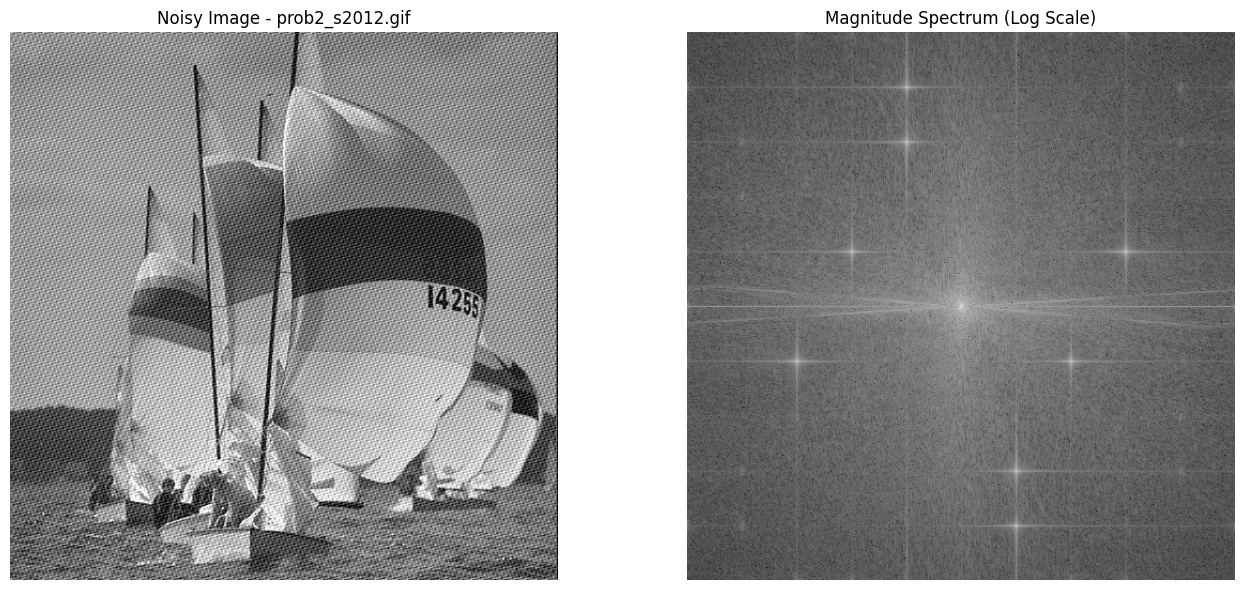

Analysis of noise in frequency domain:
Number of bright spots (potential noise): 1311
Bright spots threshold: 93870.85


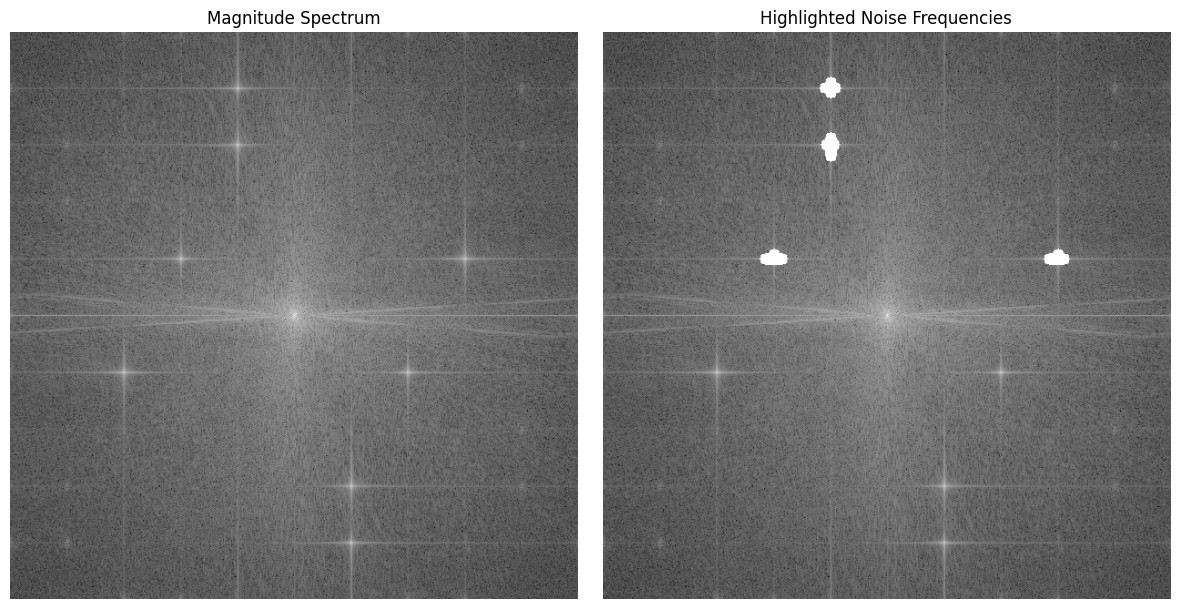

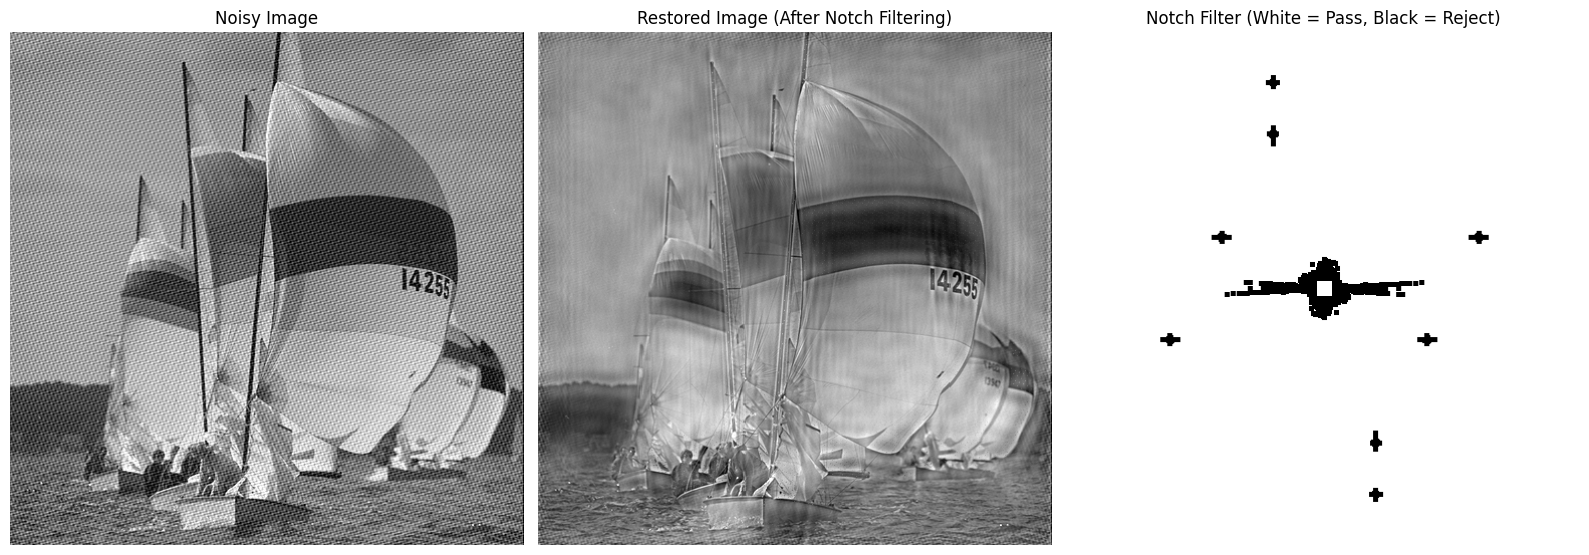

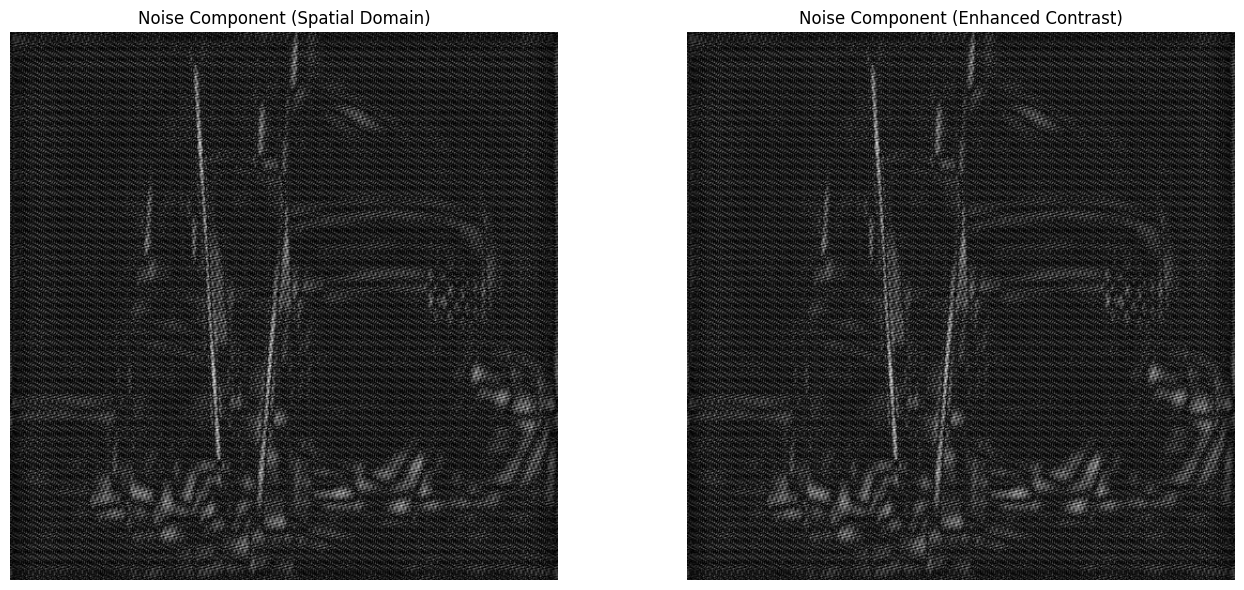

In [6]:
# Question 3: Noise Analysis and Restoration

# A) Compute and display magnitude spectrum
img_noisy = cv2.imread('./required-files/prob2_s2012.gif', cv2.IMREAD_GRAYSCALE)

if img_noisy is None:
    print("Error: Could not load prob2_s2012.gif")
else:
    rows, cols = img_noisy.shape
    center_row, center_col = rows // 2, cols // 2
    
    # Compute FFT and magnitude spectrum
    fft_noisy = np.fft.fft2(img_noisy)
    fft_noisy_shifted = np.fft.fftshift(fft_noisy)
    magnitude_noisy = np.abs(fft_noisy_shifted)
    magnitude_log = np.log(1 + magnitude_noisy)
    
    # Display original and magnitude spectrum
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_noisy, cmap='gray')
    plt.title('Noisy Image - prob2_s2012.gif')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_log, cmap='gray')
    plt.title('Magnitude Spectrum (Log Scale)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # B) Analyze noise type
    # Look for periodic patterns in frequency domain
    # Periodic noise appears as bright spots (impulses) in frequency domain
    # Check for bright spots away from center
    
    # Find bright spots in frequency domain (potential noise frequencies)
    threshold = np.percentile(magnitude_noisy, 99.5)  # Top 0.5% values
    bright_spots = np.where(magnitude_noisy > threshold)
    
    print("Analysis of noise in frequency domain:")
    print(f"Number of bright spots (potential noise): {len(bright_spots[0])}")
    print(f"Bright spots threshold: {threshold:.2f}")
    
    # Display frequency spectrum with bright spots highlighted
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(magnitude_log, cmap='gray')
    plt.title('Magnitude Spectrum')
    plt.axis('off')
    
    # Highlight bright spots
    magnitude_highlighted = magnitude_log.copy()
    if len(bright_spots[0]) > 0:
        # Mark bright spots
        for i in range(min(100, len(bright_spots[0]))):  # Show first 100 spots
            r, c = bright_spots[0][i], bright_spots[1][i]
            # Draw a small circle around bright spots
            y, x = np.ogrid[:rows, :cols]
            mask = (x - c)**2 + (y - r)**2 <= 5**2
            magnitude_highlighted[mask] = magnitude_log.max()
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_highlighted, cmap='gray')
    plt.title('Highlighted Noise Frequencies')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # C) Design notch filter to remove periodic noise
    # Create a notch filter (band-reject filter) to remove the periodic noise
    # Identify noise frequencies from bright spots
    
    # Create frequency coordinates
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    # Initialize notch filter (all ones = pass all frequencies)
    notch_filter = np.ones((rows, cols), dtype=np.float32)
    
    # Remove bright spots (noise frequencies) by creating notches
    # For each bright spot, create a small notch (zero out that frequency)
    notch_radius = 3  # Radius of notch around each noise frequency
    
    if len(bright_spots[0]) > 0:
        for i in range(len(bright_spots[0])):
            r, c = bright_spots[0][i], bright_spots[1][i]
            # Skip the DC component (center)
            if abs(r - center_row) < 10 and abs(c - center_col) < 10:
                continue
            # Create circular notch
            dist = np.sqrt((u - r)**2 + (v - c)**2)
            notch_filter[dist < notch_radius] = 0.0
    
    # Apply notch filter
    filtered_fft = fft_noisy_shifted * notch_filter
    filtered_fft_ishifted = np.fft.ifftshift(filtered_fft)
    img_restored = np.real(np.fft.ifft2(filtered_fft_ishifted))
    img_restored = np.clip(img_restored, 0, 255).astype(np.uint8)
    
    # Display results
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img_noisy, cmap='gray')
    plt.title('Noisy Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_restored, cmap='gray')
    plt.title('Restored Image (After Notch Filtering)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(notch_filter, cmap='gray')
    plt.title('Notch Filter (White = Pass, Black = Reject)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # D) Display noise component in spatial domain
    # Noise = Noisy Image - Restored Image
    noise_component = img_noisy.astype(np.float32) - img_restored.astype(np.float32)
    noise_component = np.abs(noise_component)  # Take absolute value
    noise_component = np.clip(noise_component, 0, 255).astype(np.uint8)
    
    # Enhance contrast for better visualization
    noise_enhanced = cv2.normalize(noise_component, None, 0, 255, cv2.NORM_MINMAX)
    
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(noise_component, cmap='gray')
    plt.title('Noise Component (Spatial Domain)')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(noise_enhanced, cmap='gray')
    plt.title('Noise Component (Enhanced Contrast)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Optional: Display using cv2
    show_images_cv2(['Noisy', 'Restored', 'Noise Component'], 
                    [img_noisy, img_restored, noise_enhanced])


## Question 4

For the image trucknoise.gif

**A)** Display the magnitude spectrum of the image.     
**B)** Determine the type of noise in the frequency domain.     
**C)** Can you remove the noise? Which type of filter is needed?        
**D)** Display the noise-removed image and compute the PSNR of the image (truck.gif is the original image)


<div style="display: flex;">
    <img src="./required-files/truck.gif" alt="Image 1" width="200" height="200"/>
    <img src="./required-files/trucknoise.gif" alt="Image 2" width="200" height="200"/>
</div>


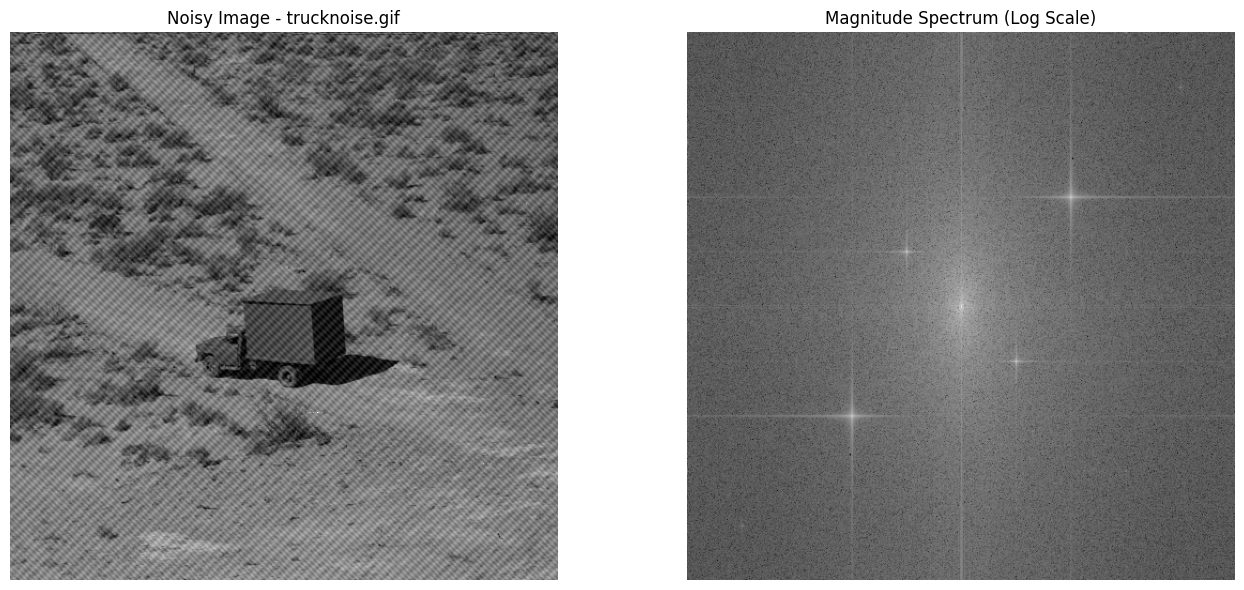

Noise Analysis:
Number of bright spots (potential periodic noise): 1311
Threshold value: 61170.33
Noise Type: PERIODIC NOISE detected
Characteristic: Bright spots (impulses) in frequency domain


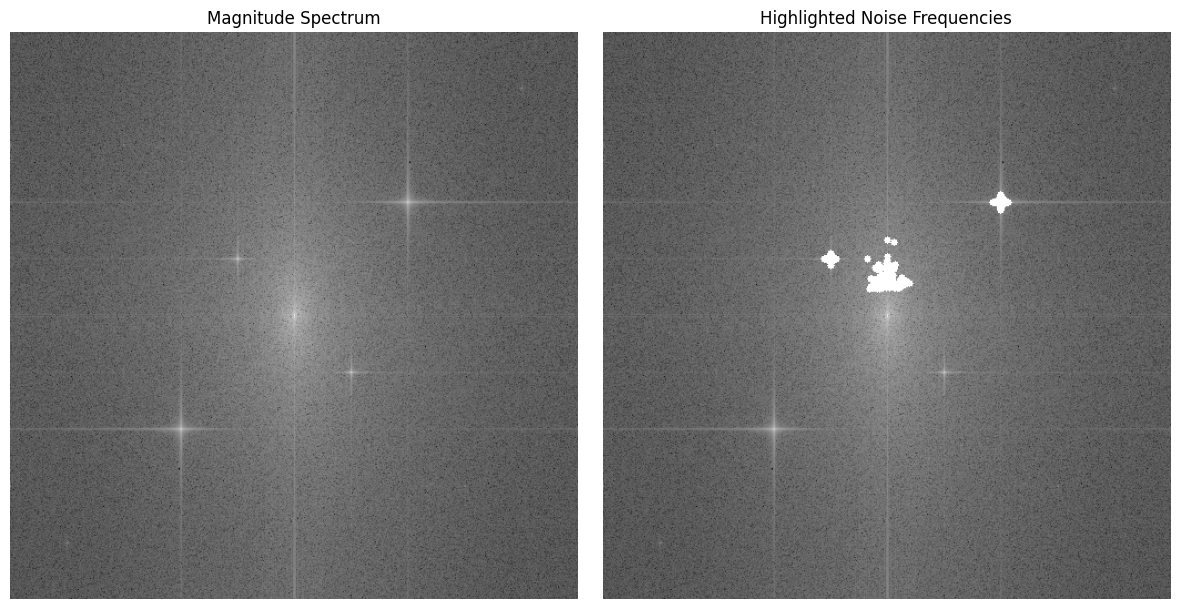


Applying Notch Filter to remove periodic noise...


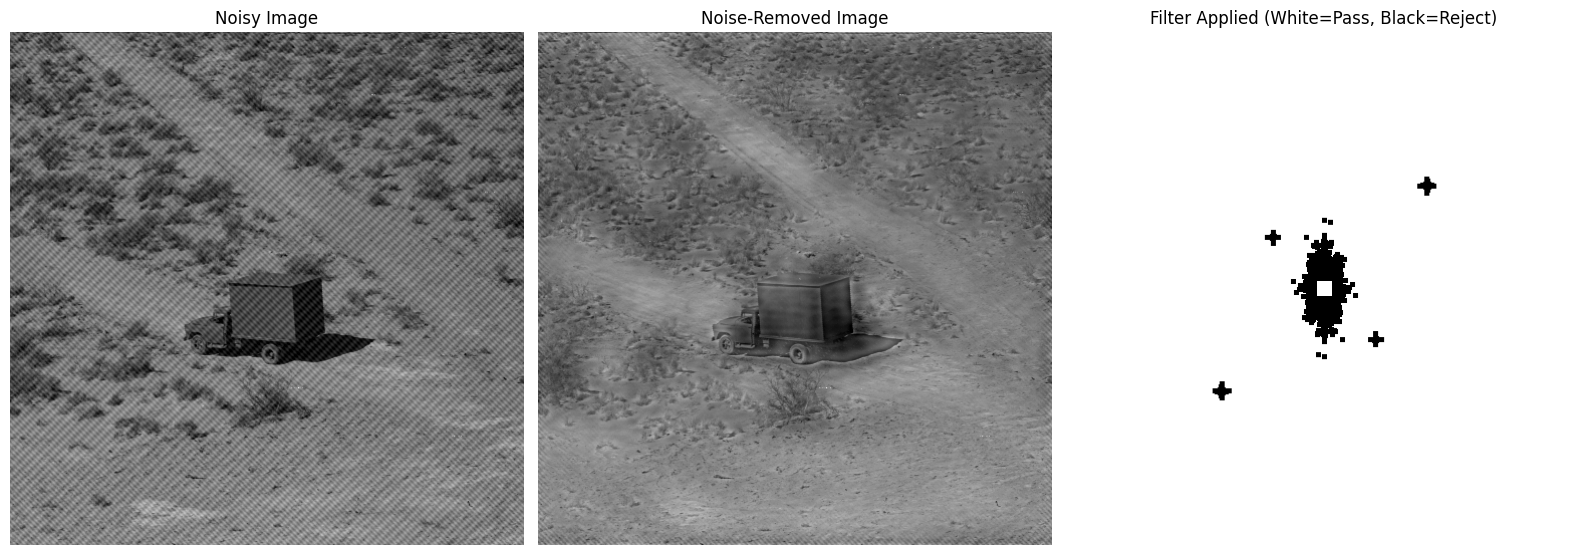


PSNR Results:
PSNR (Original vs Noisy): 24.60 dB
PSNR (Original vs Restored): 24.67 dB
Improvement: 0.08 dB


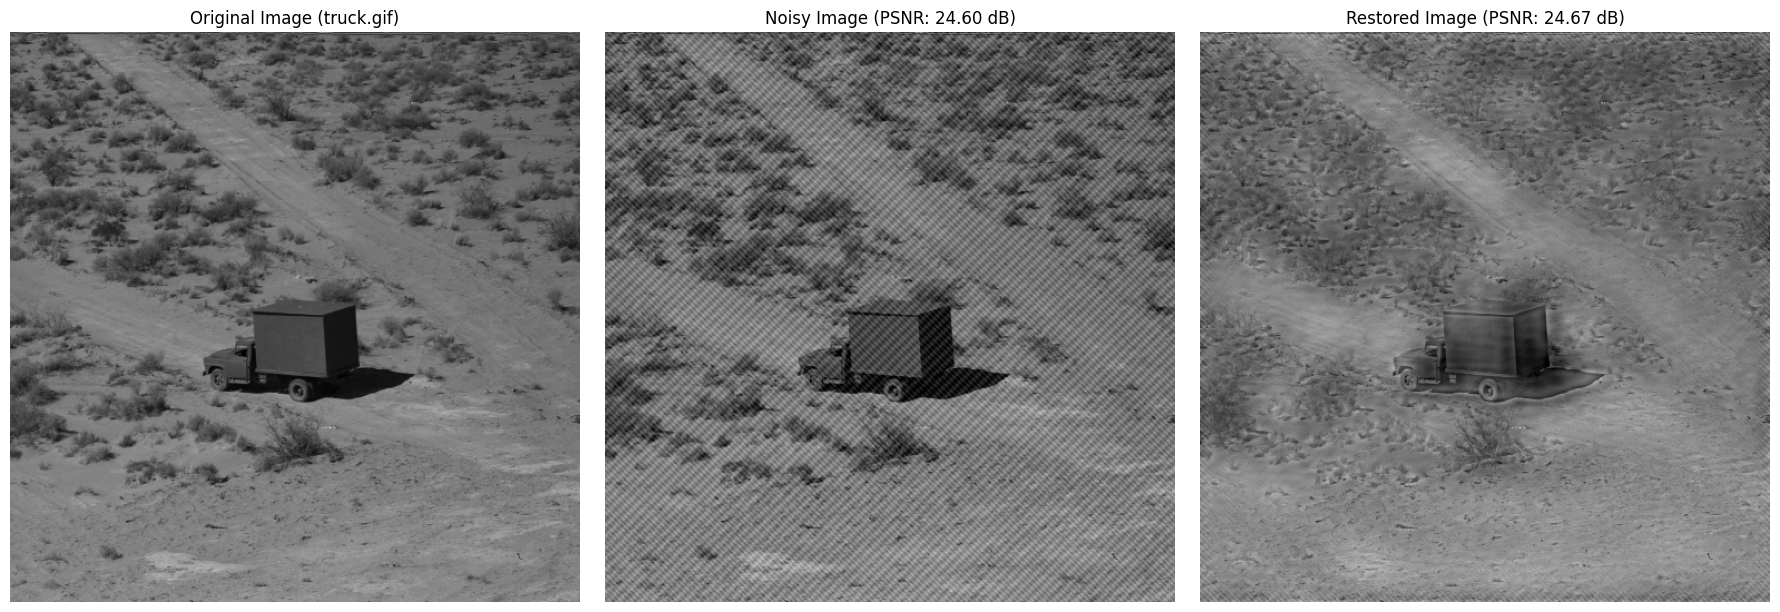

In [8]:
# Question 4: Noise Removal and PSNR Calculation

# Load original and noisy images
img_original = cv2.imread('./required-files/truck.gif', cv2.IMREAD_GRAYSCALE)
img_noisy = cv2.imread('./required-files/trucknoise.gif', cv2.IMREAD_GRAYSCALE)

if img_original is None or img_noisy is None:
    print("Error: Could not load images")
else:
    rows, cols = img_noisy.shape
    center_row, center_col = rows // 2, cols // 2
    
    # A) Display magnitude spectrum of noisy image
    fft_noisy = np.fft.fft2(img_noisy)
    fft_noisy_shifted = np.fft.fftshift(fft_noisy)
    magnitude_noisy = np.abs(fft_noisy_shifted)
    magnitude_log = np.log(1 + magnitude_noisy)
    
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_noisy, cmap='gray')
    plt.title('Noisy Image - trucknoise.gif')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_log, cmap='gray')
    plt.title('Magnitude Spectrum (Log Scale)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # B) Determine noise type in frequency domain
    # Look for periodic patterns (bright spots) in frequency domain
    threshold = np.percentile(magnitude_noisy, 99.5)
    bright_spots = np.where(magnitude_noisy > threshold)
    
    print("Noise Analysis:")
    print(f"Number of bright spots (potential periodic noise): {len(bright_spots[0])}")
    print(f"Threshold value: {threshold:.2f}")
    
    # Check if noise is periodic (bright spots away from center)
    periodic_noise_detected = False
    if len(bright_spots[0]) > 0:
        # Count bright spots away from center
        spots_away_from_center = 0
        for i in range(len(bright_spots[0])):
            r, c = bright_spots[0][i], bright_spots[1][i]
            dist_from_center = np.sqrt((r - center_row)**2 + (c - center_col)**2)
            if dist_from_center > 20:  # Away from DC component
                spots_away_from_center += 1
        
        if spots_away_from_center > 5:
            periodic_noise_detected = True
            print("Noise Type: PERIODIC NOISE detected")
            print("Characteristic: Bright spots (impulses) in frequency domain")
        else:
            print("Noise Type: Likely random/Gaussian noise")
    
    # Visualize noise frequencies
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(magnitude_log, cmap='gray')
    plt.title('Magnitude Spectrum')
    plt.axis('off')
    
    # Highlight bright spots
    magnitude_highlighted = magnitude_log.copy()
    if len(bright_spots[0]) > 0:
        for i in range(min(200, len(bright_spots[0]))):
            r, c = bright_spots[0][i], bright_spots[1][i]
            y, x = np.ogrid[:rows, :cols]
            mask = (x - c)**2 + (y - r)**2 <= 3**2
            magnitude_highlighted[mask] = magnitude_log.max()
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_highlighted, cmap='gray')
    plt.title('Highlighted Noise Frequencies')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # C) Remove noise using appropriate filter
    # Since periodic noise is detected, use notch filter (band-reject filter)
    
    # Create frequency coordinates
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    
    # Initialize notch filter
    notch_filter = np.ones((rows, cols), dtype=np.float32)
    notch_radius = 3
    
    if periodic_noise_detected and len(bright_spots[0]) > 0:
        print("\nApplying Notch Filter to remove periodic noise...")
        for i in range(len(bright_spots[0])):
            r, c = bright_spots[0][i], bright_spots[1][i]
            # Skip DC component
            if abs(r - center_row) < 10 and abs(c - center_col) < 10:
                continue
            # Create circular notch
            dist = np.sqrt((u - r)**2 + (v - c)**2)
            notch_filter[dist < notch_radius] = 0.0
    else:
        # If not periodic, try band-reject or lowpass filter
        print("\nApplying Band-Reject Filter...")
        # Create a band-reject filter (reject frequencies in a certain band)
        D = np.sqrt((u - center_row)**2 + (v - center_col)**2)
        D0 = 50  # Inner radius
        W = 20   # Bandwidth
        # Band-reject: H = 1 - bandpass
        # Bandpass: 1 / (1 + ((D*W)/(D^2 - D0^2))^2)
        H_br = 1 - (1 / (1 + ((D * W) / (D**2 - D0**2 + 1e-10))**2))
        notch_filter = H_br
    
    # Apply filter
    filtered_fft = fft_noisy_shifted * notch_filter
    filtered_fft_ishifted = np.fft.ifftshift(filtered_fft)
    img_restored = np.real(np.fft.ifft2(filtered_fft_ishifted))
    img_restored = np.clip(img_restored, 0, 255).astype(np.uint8)
    
    # Display filter and results
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img_noisy, cmap='gray')
    plt.title('Noisy Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_restored, cmap='gray')
    plt.title('Noise-Removed Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(notch_filter, cmap='gray')
    plt.title('Filter Applied (White=Pass, Black=Reject)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # D) Compute PSNR
    def calculate_psnr(img1, img2):
        """
        Calculate Peak Signal-to-Noise Ratio (PSNR)
        PSNR = 20 * log10(MAX_I / sqrt(MSE))
        where MSE = mean squared error
        """
        # Ensure images are same size
        if img1.shape != img2.shape:
            print("Warning: Images have different sizes")
            return None
        
        # Convert to float for calculation
        img1 = img1.astype(np.float64)
        img2 = img2.astype(np.float64)
        
        # Calculate MSE
        mse = np.mean((img1 - img2) ** 2)
        
        if mse == 0:
            return float('inf')  # Images are identical
        
        # Maximum pixel value (for 8-bit images, it's 255)
        MAX_I = 255.0
        
        # Calculate PSNR
        psnr = 20 * np.log10(MAX_I / np.sqrt(mse))
        
        return psnr
    
    # Calculate PSNR between original and restored image
    psnr_value = calculate_psnr(img_original, img_restored)
    
    # Also calculate PSNR between original and noisy image for comparison
    psnr_noisy = calculate_psnr(img_original, img_noisy)
    
    print("\nPSNR Results:")
    print(f"PSNR (Original vs Noisy): {psnr_noisy:.2f} dB")
    print(f"PSNR (Original vs Restored): {psnr_value:.2f} dB")
    print(f"Improvement: {psnr_value - psnr_noisy:.2f} dB")
    
    # Display comparison
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Image (truck.gif)')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_noisy, cmap='gray')
    plt.title(f'Noisy Image (PSNR: {psnr_noisy:.2f} dB)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_restored, cmap='gray')
    plt.title(f'Restored Image (PSNR: {psnr_value:.2f} dB)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Optional: Display using cv2
    show_images_cv2(['Original', 'Noisy', 'Restored'], 
                    [img_original, img_noisy, img_restored])


**Explanation**

**A) Magnitude Spectrum**
- The magnitude spectrum shows the frequency content of the noisy image.
- Periodic noise appears as distinct bright spots (impulses) in the frequency domain.

**B) Noise Type Identification**
- **Periodic Noise**: Characterized by bright spots away from the center in frequency domain.
- These bright spots represent specific frequency components that are corrupting the image.
- Periodic noise is typically caused by electrical interference, mechanical vibrations, or periodic patterns in the imaging system.

**C) Filter Selection and Noise Removal**
- **Notch Filter**: Used to remove periodic noise by creating "notches" (zeros) at specific noise frequencies.
- The filter is designed to reject frequencies where bright spots are detected.
- The filter is applied in the frequency domain by multiplying the FFT of the image with the filter.
- Alternative: Band-reject filter can be used if the noise occupies a frequency band rather than specific frequencies.

**D) PSNR (Peak Signal-to-Noise Ratio)**
- **Formula**: `PSNR = 20 * log10(MAX_I / sqrt(MSE))`
- **MSE (Mean Squared Error)**: Average of squared differences between original and processed images.
- **Interpretation**:
  - Higher PSNR = Better image quality (less distortion)
  - Typical values: 20-30 dB (acceptable), 30-40 dB (good), >40 dB (excellent)
- PSNR measures the quality of the restored image compared to the original.
- The improvement in PSNR after filtering indicates the effectiveness of the noise removal process.
